In [3]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
#converting api endpoints to data frames
owners_url = "https://www.fema.gov/api/open/v2/HousingAssistanceOwners"
renters_url = "https://www.fema.gov/api/open/v2/HousingAssistanceRenters"

def fetch_all(url, params):
    all_data = []
    skip = 0
    key = url.split("/")[-1]  #gets "HousingAssistanceOwners" or "HousingAssistanceRenters"
    
    while True:
        params["$skip"] = skip
        response = requests.get(url, params=params).json()[key]
        
        if not response:
            break
            
        all_data.extend(response)
        
        if len(response) < 1000:  #last page
            break
            
        skip += 1000
    
    return all_data

params = {
    "$filter": "disasterNumber eq 4827",
    "$select": "state,validRegistrations,approvedForFemaAssistance,totalApprovedIhpAmount",
    "$top": 1000,
    "$format": "json"
}

owners_df = pd.DataFrame(fetch_all(owners_url, params.copy()))
renters_df = pd.DataFrame(fetch_all(renters_url, params.copy()))

print(len(owners_df), len(renters_df))

1409 1457


In [5]:
#approval rate and average award by group

def summarize(df):
    df["validRegistrations"] = pd.to_numeric(df["validRegistrations"], errors="coerce")
    df["approvedForFemaAssistance"] = pd.to_numeric(df["approvedForFemaAssistance"], errors="coerce")
    df["totalApprovedIhpAmount"] = pd.to_numeric(df["totalApprovedIhpAmount"], errors="coerce")
    total_reg = df["validRegistrations"].sum()
    total_approved = df["approvedForFemaAssistance"].sum()
    total_amount = df["totalApprovedIhpAmount"].sum()
    approval_rate = (total_approved / total_reg) * 100
    avg_award = total_amount / total_approved
    return round(approval_rate, 1), round(avg_award, 0)

owner_rate, owner_award = summarize(owners_df)
renter_rate, renter_award = summarize(renters_df)

print(owner_rate, owner_award)
print(renter_rate, renter_award)

61.4 4511.0
50.5 1680.0


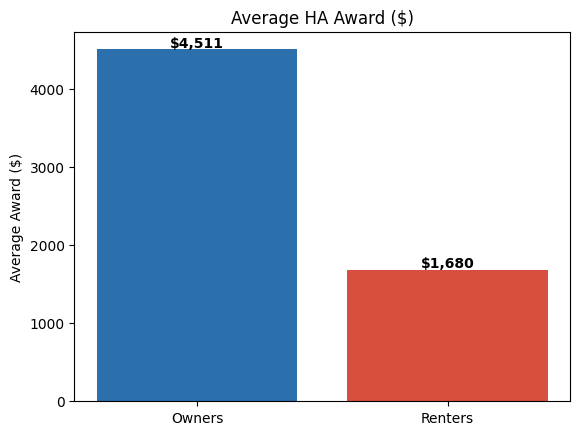

In [6]:
#create plot of average award for PRESS RELEASE

ax1 = plt.subplot()


ax1.bar(["Owners", "Renters"], [owner_award, renter_award], color=["#2c6fad", "#d94f3d"])
ax1.set_title("Average HA Award ($)")
ax1.set_ylabel("Average Award ($)")
for i, v in enumerate([owner_award, renter_award]):
    ax1.text(i, v + 30, f"${v:,.0f}", ha="center", fontweight="bold")

import os
os.makedirs("output", exist_ok=True)
fig = plt.gcf()
fig.savefig("output/average_award.png", bbox_inches="tight")

Average housing assistance award per applicant following Hurricane Helene (Disaster \#4827), comparing FEMA aid received by homeowners versus renters. Homeowners received on average 2.5x more assistance than renters ($4,230 vs. $1,693), highlighting a systematic disparity in emergency resource allocation.

In [7]:
#converting api endpoints to data frames
owners_url = "https://www.fema.gov/api/open/v2/HousingAssistanceOwners"
renters_url = "https://www.fema.gov/api/open/v2/HousingAssistanceRenters"

def fetch_all(url, params):
    all_data = []
    skip = 0
    key = url.split("/")[-1]  #gets "HousingAssistanceOwners" or "HousingAssistanceRenters"
    
    while True:
        params["$skip"] = skip
        response = requests.get(url, params=params).json()[key]
        
        if not response:
            break
            
        all_data.extend(response)
        
        if len(response) < 1000:  #last page
            break
            
        skip += 1000
    
    return all_data

params = {
    "$filter": "disasterNumber eq 4827",
    "$select": "state,validRegistrations,approvedForFemaAssistance,totalApprovedIhpAmount",
    "$top": 1000,
    "$format": "json"
}

owners_df = pd.DataFrame(fetch_all(owners_url, params.copy()))
renters_df = pd.DataFrame(fetch_all(renters_url, params.copy()))

print(len(owners_df), len(renters_df))

1409 1457


In [8]:
print(owners_df.dtypes)
print()
print(owners_df.head(2))
print()
print(owners_df.isnull().sum())

state                         object
validRegistrations             int64
approvedForFemaAssistance      int64
totalApprovedIhpAmount       float64
dtype: object

  state  validRegistrations  approvedForFemaAssistance  totalApprovedIhpAmount
0    NC                   2                          2                 8220.63
1    NC                   1                          1                  750.00

state                        0
validRegistrations           0
approvedForFemaAssistance    0
totalApprovedIhpAmount       0
dtype: int64


In [9]:
renters_df['state'].nunique()
print(renters_df['state'].unique())

['NC' 'SC']


In [10]:
print(owners_df[['validRegistrations', 'approvedForFemaAssistance', 'totalApprovedIhpAmount']].describe())
print()
print(renters_df[['validRegistrations', 'approvedForFemaAssistance', 'totalApprovedIhpAmount']].describe())

       validRegistrations  approvedForFemaAssistance  totalApprovedIhpAmount
count         1409.000000                1409.000000            1.409000e+03
mean           120.066004                  73.721079            3.325889e+05
std            543.902171                 388.935729            1.865787e+06
min              1.000000                   0.000000            0.000000e+00
25%              1.000000                   0.000000            0.000000e+00
50%              2.000000                   1.000000            3.000000e+02
75%             14.000000                   3.000000            1.312248e+04
max           7354.000000                5555.000000            3.206580e+07

       validRegistrations  approvedForFemaAssistance  totalApprovedIhpAmount
count         1457.000000                1457.000000            1.457000e+03
mean            77.470144                  39.154427            6.577980e+04
std            422.839258                 249.493339            3.829549e+0